# Assignment 2: Titanic Logistic Regression
**Student:** Brittny Ellington  
**Course:** Intro to Machine Learning Models  
**Goal:** Run and explain the provided Titanic logistic-regression notebook.


# Titanic Dataset Analysis

From Kaggle: The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

# Tasks:



1.   Every step must have an explanation
2.   Every plot/ chart must have an iterpretation
3.   Add your observations for each section
4.   Draw clear conclusions (at least 5 conclusions)



### What this cell is doing
This imports **Pandas**, the Python library I use to work with table-like data. I will use it to load the Titanic CSV file into a DataFrame and manage the rows and columns.

In [1]:
import pandas as pd

### What this cell is doing
This loads the Titanic training data from an online CSV file and saves it in a DataFrame named `train`. A DataFrame is basically a spreadsheet inside Python.

In [2]:
train = pd.read_csv('https://raw.githubusercontent.com/niteen11/data301_predictive_analytics_machine_learning/main/data/titanic_train.csv')

### What this cell is doing
`head()` displays the first five rows so I can quickly inspect the dataset, see the column names, and confirm that the data loaded correctly.

In [3]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


# EDA (Exploratory Data Analysis)

### What this cell is doing
This imports **Seaborn**, a visualization library. I will use it to make quick charts that help me understand the data before building the model.

In [31]:
import seaborn as sns

### What this cell is doing
This imports Matplotlib for plotting and tells the notebook to display charts directly under the code cells.

In [32]:
%matplotlib inline
import matplotlib.pyplot as plt

### What this cell is doing
This creates a heatmap of missing values. The colored marks show where data is missing so I can decide which columns may need to be cleaned, filled in, or removed.

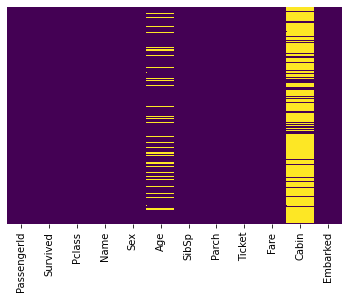

In [33]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

### Interpretation
The heatmap shows that **Cabin has the most missing data**, Age has a noticeable amount of missing data, and Embarked has only a small amount missing. Most other columns are complete.

### Observation
The dataset needs cleaning before modeling because logistic regression cannot use these missing values as-is.

## Class


### What this cell is doing
This counts how many passengers are in each value of the target column `Survived`. In this dataset, `0` means the passenger did not survive and `1` means the passenger survived.

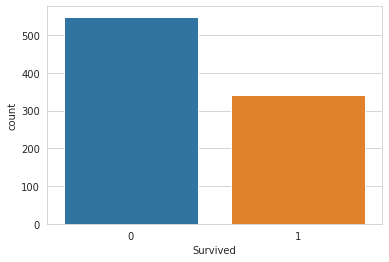

In [34]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train)

### Interpretation
There are more passengers with `Survived = 0` than `Survived = 1`, so more people in this dataset died than survived.

### Observation
The target is not perfectly balanced. This matters when evaluating the model because accuracy by itself may not tell the whole story.

## Survived

### What this cell is doing
This compares survival counts by sex. The `hue='Sex'` part splits each survival category into male and female groups.

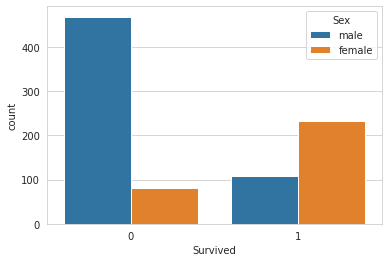

In [38]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train)

### Interpretation
The chart shows a large difference by sex. Many more males are in the non-survivor group, while females make up a much larger share of the survivor group.

### Observation
Sex appears to have useful predictive information for survival in this dataset.

### What this cell is doing
This compares survival counts by passenger class. `Pclass` represents first, second, or third class.

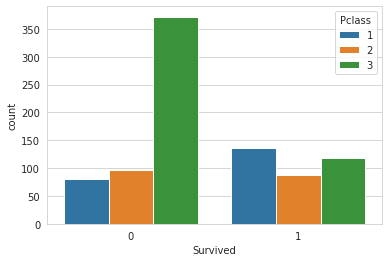

In [ ]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train)

### Interpretation
Third-class passengers make up the largest group of non-survivors. First-class passengers have a much stronger representation among survivors than among non-survivors.

### Observation
Passenger class appears related to survival and may be a useful feature for the model.

## Age

### What this cell is doing
This creates a histogram of passenger ages after temporarily ignoring missing age values. The bars show how frequently different age ranges appear in the dataset.

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


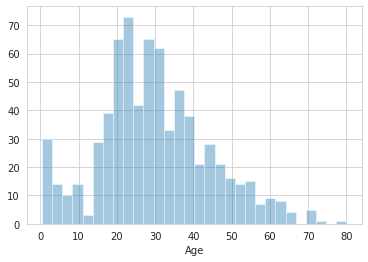

In [71]:
sns.distplot(train['Age'].dropna(), kde=False, bins=30)

### Interpretation
Most passengers with known ages are young or middle-aged adults, with the largest concentration around the 20s and 30s. There are fewer older passengers.

### Observation
This chart describes the **age distribution only**. By itself, it does not show whether age increased or decreased the chance of survival.

## Siblings

### What this cell is doing
This counts the `SibSp` values, which represent how many siblings or spouses a passenger had aboard the Titanic.

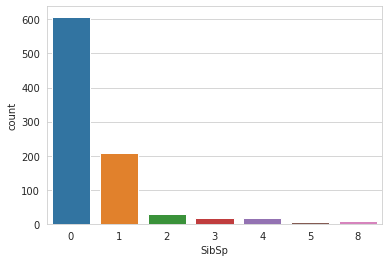

In [46]:
sns.countplot(x='SibSp',data=train)

### Interpretation
Most passengers had `SibSp = 0`, and the next largest group had `SibSp = 1`. Larger numbers of siblings/spouses aboard were uncommon.

### Observation
The dataset contains many passengers who traveled without a sibling or spouse.

# Data Cleaning and Data Pre - Processing

### What this cell is doing
This removes the `Cabin` column. The earlier missing-value heatmap showed that Cabin has a very large amount of missing data, so the provided notebook drops it instead of trying to fill in so many unknown values.

In [42]:
train.drop('Cabin', axis=1, inplace= True)

### What this cell is doing
This removes any remaining rows that contain missing values.

**Tradeoff:** This is simple and avoids inventing replacement values, but it also removes real passenger records. Because a noticeable amount of Age data is missing, dropping these rows can introduce bias by changing which passengers remain in the dataset.

In [ ]:
train.dropna(inplace=True)

### What this cell is doing
A machine-learning model needs numeric inputs. `get_dummies()` converts the text categories in `Sex` and `Embarked` into numeric indicator columns. `drop_first=True` removes one redundant category from each set.

In [ ]:
sex = pd.get_dummies(train['Sex'], drop_first=True)
embark = pd.get_dummies(train['Embarked'], drop_first=True)

### What this cell is doing
This removes the original text columns after encoding `Sex` and `Embarked`. It also removes `Name` and `Ticket`, which are not being used as predictors in this provided model.

In [ ]:
train.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace= True)

### What this cell is doing
`head()` displays the first five rows so I can quickly inspect the dataset, see the column names, and confirm that the data loaded correctly.

In [43]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


### What this cell is doing
This adds the newly encoded numeric `Sex` and `Embarked` columns back into the cleaned Titanic DataFrame.

In [44]:
train = pd.concat([train, sex, embark],axis=1)

### What this cell is doing
`head()` displays the first five rows so I can quickly inspect the dataset, see the column names, and confirm that the data loaded correctly.

In [45]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


# Model building

### What this cell is doing
This imports the Scikit-learn function used to divide the data into a **training set** and a **testing set**.

In [59]:
from sklearn.model_selection import train_test_split

### What this cell is doing
This separates the predictors (`X`) from the target (`y`) and then splits them into training and testing data.

- `X` = the clues/features used to make the prediction.
- `y` = `Survived`, the answer the model is trying to predict.
- `test_size=0.3` means 30% of the data is held out for testing and 70% is used for training.
- `random_state=101` makes the split reproducible, so the same rows are placed into the train and test sets each time the notebook is run.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1), train['Survived'],test_size=0.3, random_state=101)

### What this cell is doing
This imports the **Logistic Regression** algorithm. Logistic regression is appropriate here because the target has two categories: survived (`1`) or did not survive (`0`).

In [61]:
from sklearn.linear_model import LogisticRegression

### What this cell is doing
This creates a new logistic regression model object named `logmodel`. At this point the model exists, but it has not learned from the Titanic data yet.

In [62]:
logmodel = LogisticRegression()

### What this cell is doing
`fit()` trains the model. The model studies the relationship between the training features in `X_train` and the known survival answers in `y_train`.

If Colab shows a **ConvergenceWarning**, that is a warning rather than a failed cell. It means the solver reached its default iteration limit before fully settling on the coefficients.

In [63]:
logmodel.fit(X_train, y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

### What this cell is doing
This asks the trained model to predict survival (`0` or `1`) for the passengers in the test set. These predictions are stored in `predict`.

In [64]:
predict = logmodel.predict(X_test)

## Classification report

### What this cell is doing
This imports the classification report, which gives several ways to evaluate a classification model, including precision, recall, F1-score, and support.

In [65]:
from sklearn.metrics import classification_report

### What this cell is doing
This compares the model's predictions with the real answers in `y_test` and prints the evaluation report.

In [66]:
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       128
           1       0.72      0.70      0.71        86

    accuracy                           0.77       214
   macro avg       0.76      0.76      0.76       214
weighted avg       0.77      0.77      0.77       214



### Interpretation of the saved report
In the provided notebook output:

- Class `0` (did not survive): precision ≈ **0.80**, recall ≈ **0.82**, F1 ≈ **0.81**
- Class `1` (survived): precision ≈ **0.72**, recall ≈ **0.70**, F1 ≈ **0.71**
- Overall accuracy ≈ **0.77**

### Observation
The model performs better on class `0` than on class `1`. That fits what we saw earlier: the dataset contains more non-survivors, so the model has more examples of that class to learn from.

## Confusion Matrix

### What this cell is doing
This imports the confusion matrix and prints the four possible classification outcomes: correct `0`, incorrect `1`, incorrect `0`, and correct `1` predictions.

In [67]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, predict))

[[105  23]
 [ 26  60]]


### Interpretation of the saved confusion matrix
The saved matrix is:

`[[105, 23], [26, 60]]`

Using class `1` as the positive class, this means:

- **105 true negatives:** correctly predicted that the passenger did not survive
- **23 false positives:** predicted survival, but the passenger did not survive
- **26 false negatives:** predicted no survival, but the passenger actually survived
- **60 true positives:** correctly predicted that the passenger survived

The model made **165 correct predictions out of 214 test records**, which is about **77% accuracy**.

### What this cell is doing
This turns the confusion matrix into a labeled heatmap and also displays the model's accuracy score. The visual makes the correct and incorrect predictions easier to compare.

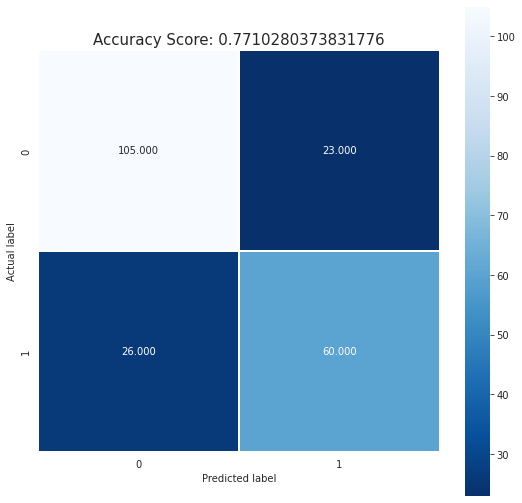

In [68]:
plt.figure(figsize=(9,9))
sns.heatmap(confusion_matrix(y_test, predict), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(logmodel.score(X_test, y_test))
plt.title(all_sample_title, size = 15);

### Interpretation
The confusion-matrix heatmap makes the same result visual. The largest number is the correctly predicted non-survivor group, which again shows that the model is stronger at identifying class `0` than class `1`.

### What this cell is doing
This imports Scikit-learn's metrics tools so I can create another evaluation plot for the classifier.

In [69]:
from sklearn import  metrics

### What this cell is doing
This creates an ROC curve to show how well the model separates the two classes across different decision thresholds. The Area Under the Curve (AUC) summarizes that separation ability.

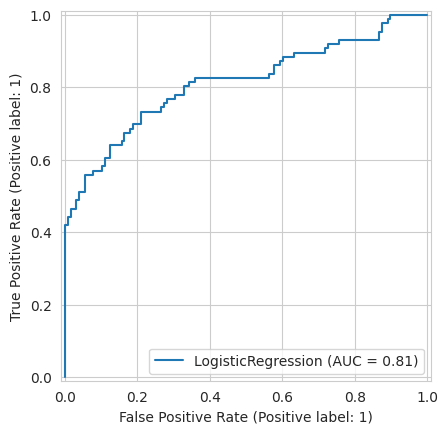

In [70]:
# Updated equivalent of the older metrics.plot_roc_curve() call
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(logmodel, X_test, y_test)
plt.show()


### Interpretation
The saved notebook shows an **AUC of about 0.81**. This indicates that the model has useful ability to distinguish survivors from non-survivors, although it is not perfect.

Observation..

# Conclusion...

## Overall observations

1. The original dataset contains both numeric and text columns, so some preprocessing is required before modeling.
2. Missing values are concentrated mainly in Cabin and Age.
3. The target is somewhat imbalanced because there are more non-survivors than survivors.
4. Sex and passenger class show clear differences in the EDA charts and appear relevant to survival.
5. The provided cleaning approach drops rows with remaining missing values rather than imputing Age. This is fast and avoids artificial values, but it can also introduce bias by removing passenger records.
6. The model uses a 70/30 train-test split so it learns from one portion of the data and is evaluated on data it did not train on.


# Conclusion

Based on the provided notebook and its saved outputs, I reached the following conclusions:

1. **More passengers in the dataset did not survive than survived.** This creates some class imbalance and is one reason to look beyond accuracy alone.
2. **Sex appears strongly related to survival.** The EDA chart shows many more male non-survivors and a much larger proportion of female survivors.
3. **Passenger class also appears related to survival.** Third-class passengers account for the largest group of deaths, while first-class passengers are more strongly represented among survivors.
4. **The dataset required preprocessing before logistic regression could be used.** Missing values had to be addressed, text variables had to be converted to numbers, and unused text columns were removed.
5. **The logistic-regression model achieved about 77% accuracy in the saved notebook output.** It performed better on predicting class `0` (did not survive) than class `1` (survived).
6. **The confusion matrix shows 105 correct non-survivor predictions and 60 correct survivor predictions**, compared with 23 false positives and 26 false negatives.
7. **The saved ROC curve has an AUC of about 0.81**, showing that the model has meaningful ability to separate the two classes, while still leaving room for improvement.
8. **Model evaluation depends on context.** Because the two target classes are not perfectly balanced, precision, recall, F1-score, and the confusion matrix provide useful information that overall accuracy alone can hide.
